In [11]:
# !pip install matplotlib

In [12]:
import json
import csv
import matplotlib.pyplot as plt

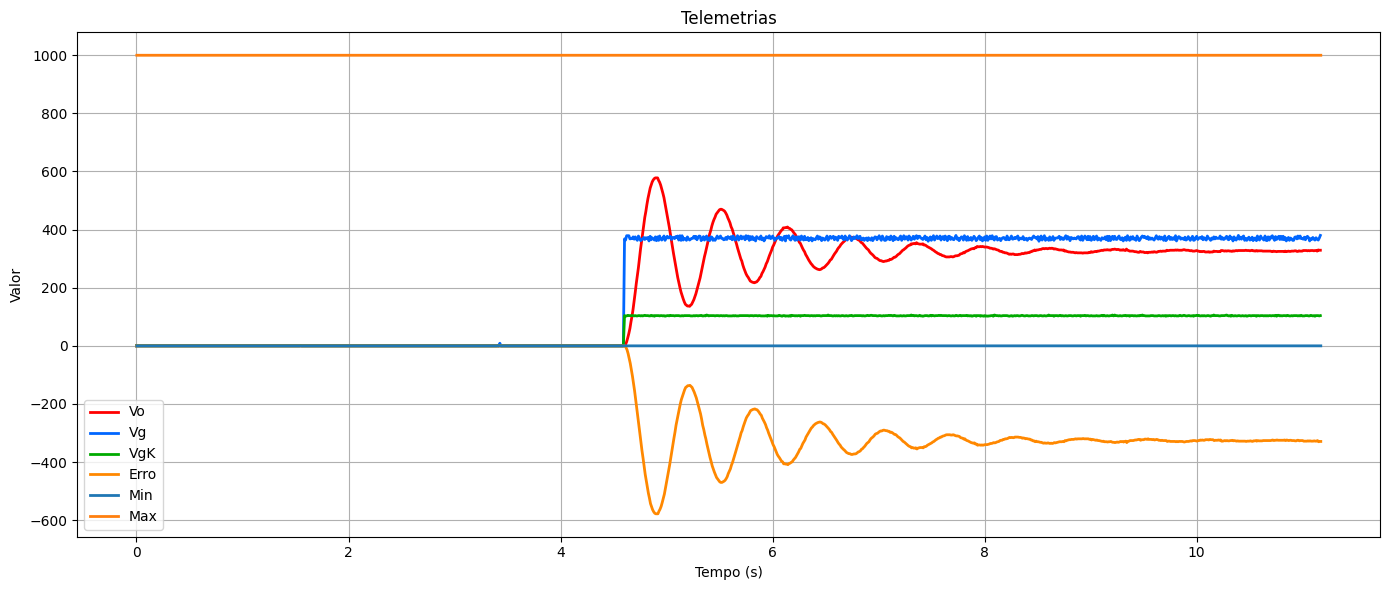

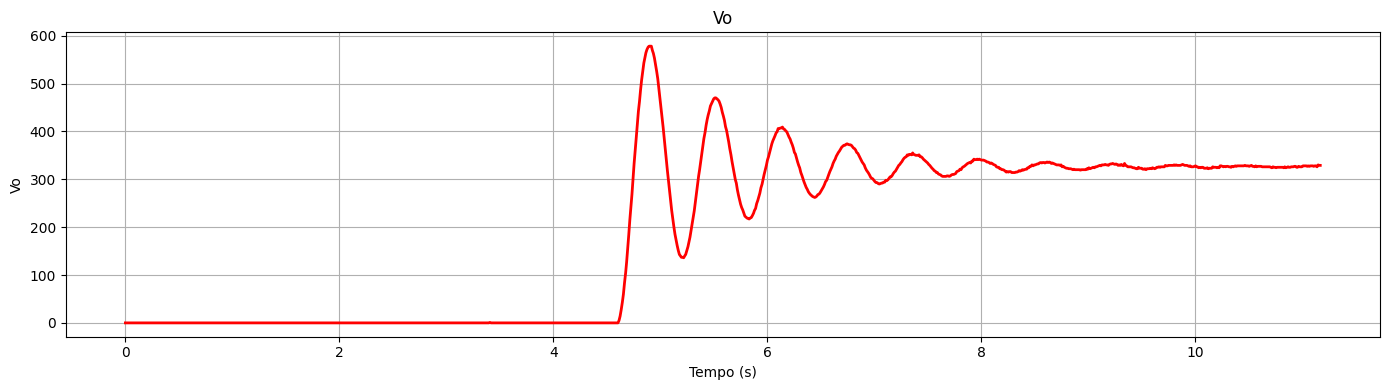

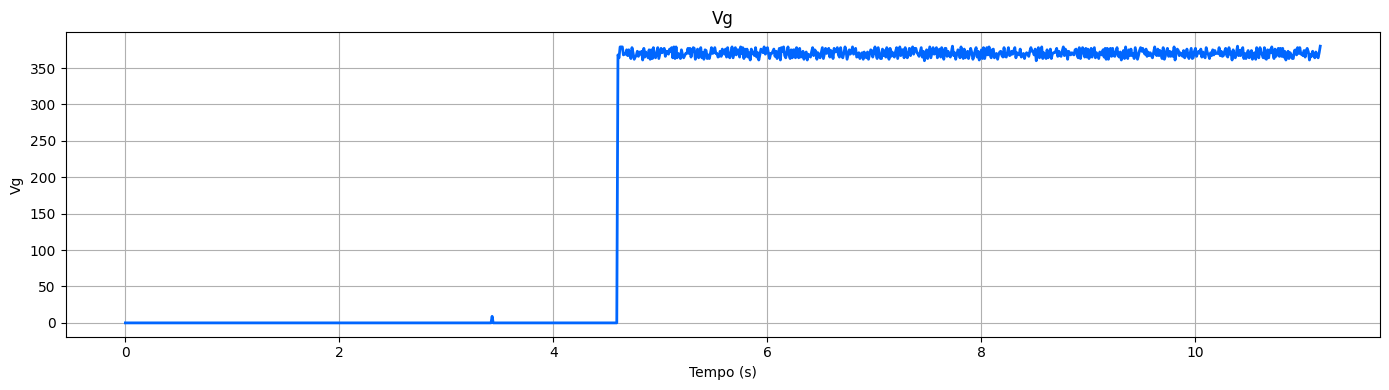

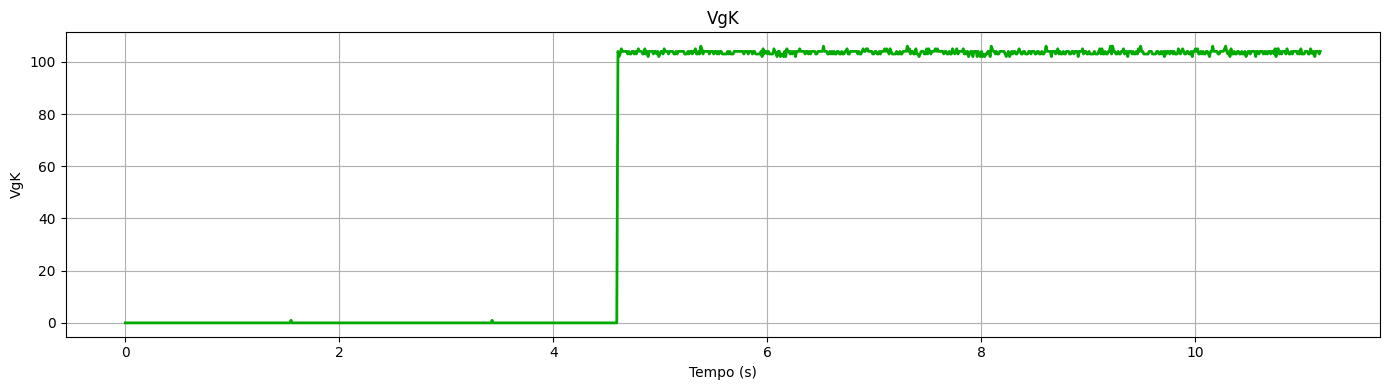

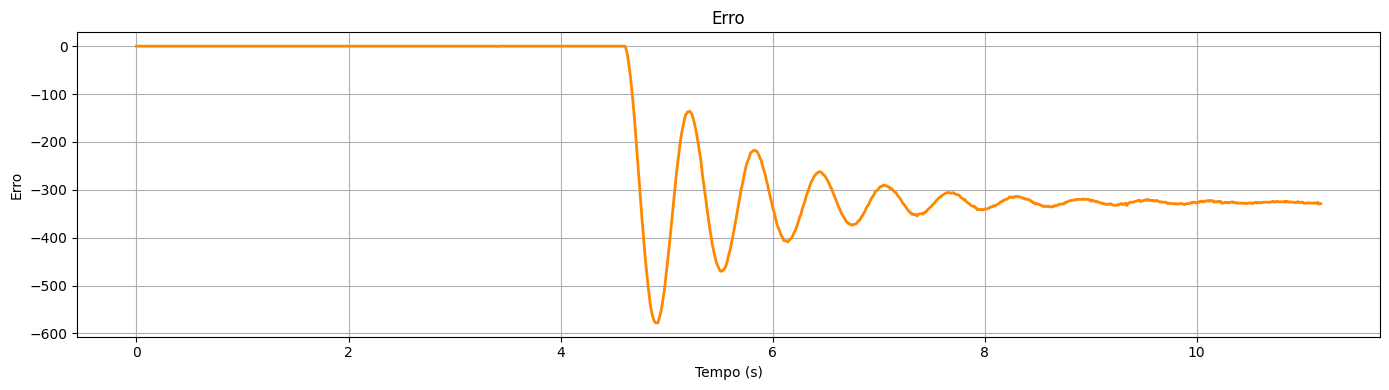

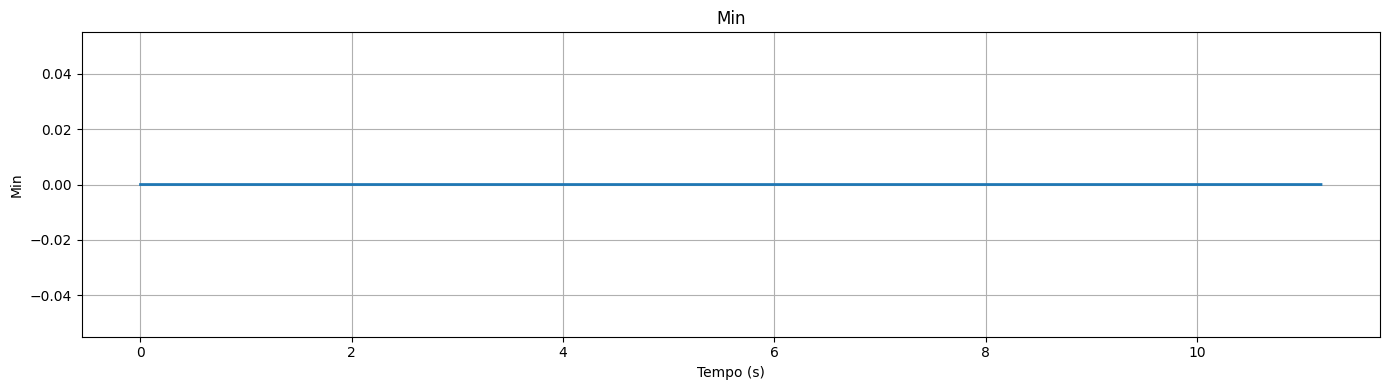

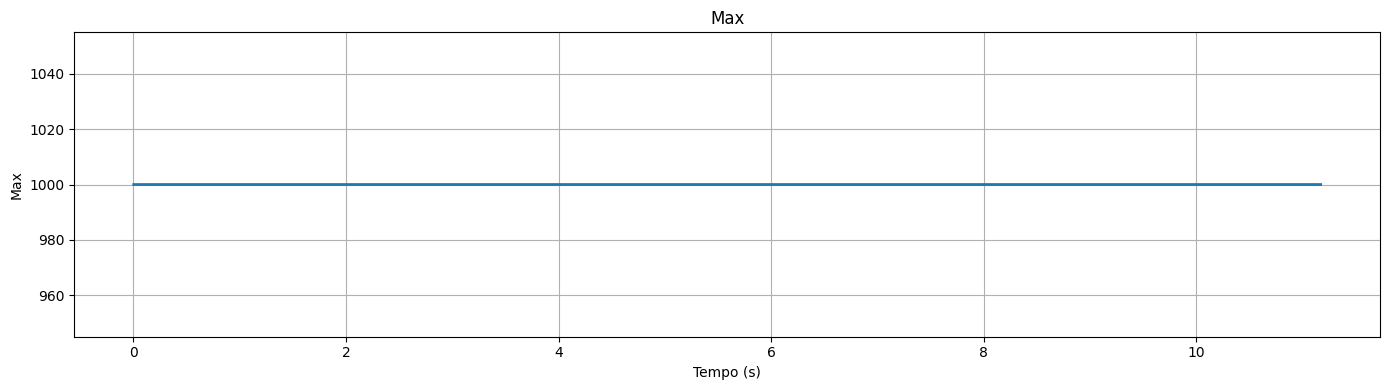

In [13]:
# ==========================================
# CORES FIXAS PARA CADA SINAL
# ==========================================

COLORS = {
    "Vg": "#0066FF",      # Azul
    "Vo": "#FF0000",      # Vermelho
    "VgK": "#00AA00",     # Verde
    "Erro": "#FF8800",    # Laranja
}

# ==========================================
# FUNÇÃO DE PLOT
# ==========================================

def plot_teleplot(
    json_file,
    signals=None,
    mode="together",      # together ou separate
    relative_time=True
):

    with open(json_file, "r") as f:
        data = json.load(f)

    telemetries = data["telemetries"]

    # Se não informar sinais, pega todos
    if signals is None:
        signals = list(telemetries.keys())

    # Verifica se os sinais existem
    for s in signals:
        if s not in telemetries:
            raise ValueError(f"Sinal '{s}' não encontrado.")

    # Tempo inicial para tempo relativo
    if relative_time:
        t0 = min(
            telemetries[s]["data"][0][0]
            for s in signals
            if len(telemetries[s]["data"][0]) > 0
        )

    # ==========================================
    # TODOS JUNTOS
    # ==========================================

    if mode.lower() == "together":

        plt.figure(figsize=(14, 6))

        for s in signals:

            t = telemetries[s]["data"][0]
            y = telemetries[s]["data"][1]

            if relative_time:
                t = [x - t0 for x in t]

            plt.plot(
                t,
                y,
                linewidth=2,
                label=s,
                color=COLORS.get(s, None)
            )

        plt.title("Telemetrias")
        plt.xlabel("Tempo (s)")
        plt.ylabel("Valor")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # ==========================================
    # SEPARADOS
    # ==========================================

    elif mode.lower() == "separate":

        for s in signals:

            t = telemetries[s]["data"][0]
            y = telemetries[s]["data"][1]

            if relative_time:
                t = [x - t0 for x in t]

            plt.figure(figsize=(14, 4))

            plt.plot(
                t,
                y,
                linewidth=2,
                color=COLORS.get(s, None)
            )

            plt.title(s)
            plt.xlabel("Tempo (s)")
            plt.ylabel(s)
            plt.grid(True)

            plt.tight_layout()
            plt.show()

    else:
        raise ValueError("mode deve ser 'together' ou 'separate'")


# ==========================================
# EXEMPLOS DE USO
# ==========================================

# Todos os sinais juntos
plot_teleplot(
    "teleplot_2026-6-7_16-52.json",
    mode="together"
)

# Todos os sinais separados
plot_teleplot(
    "teleplot_2026-6-7_16-52.json",
    mode="separate"
)

# Apenas alguns sinais juntos
# plot_teleplot(
#     "teleplot_2026-6-7_16-52.json",
#     signals=["Vg", "Vo", "VgK", "Erro"],
#     mode="together"
# )

# Apenas alguns sinais separados
# plot_teleplot(
#     "teleplot_2026-6-7_16-52.json",
#     signals=["Vg", "Vo", "VgK", "Erro"],
#     mode="separate"
# )

In [14]:

json_file = "teleplot_2026-6-7_16-52.json"
csv_file = "Vo.csv"

with open(json_file, "r") as f:
    data = json.load(f)

vo = data["telemetries"]["Vo"]

tempo = vo["data"][0]
valor = vo["data"][1]

with open(csv_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["tempo", "Vo"])

    for t, v in zip(tempo, valor):
        writer.writerow([t, v])

print(f"Arquivo salvo: {csv_file}")

Arquivo salvo: Vo.csv


In [21]:
import numpy as np

ts = 10e-3  # 0,01 s
n = 61
k=329/353
wn = 2*np.pi/(n*ts)

print("Wn: "+str(wn))
print("K: "+str(k))

Wn: 10.300303782261617
K: 0.9320113314447592
